# 🔭 SDSS Yıldız/Galaksi/Kuasar Sınıflandırması — XGBoost Classifier

**🇹🇷 Türkçe:**
Bu notebook, **Sloan Digital Sky Survey (SDSS) DR14** kataloğundaki 10.000 gök cismini üç sınıfa ayırıyor: **yıldız (STAR)**, **galaksi (GALAXY)** ve **kuasar (QSO)**.

Kullanılan özellikler cismin beş farklı filtreden (`u`, `g`, `r`, `i`, `z`) ölçülen parlaklığı, gökyüzündeki konumu (`ra`, `dec`) ve **kırmızıya kayma** (`redshift`) değeri. Model olarak `XGBClassifier` kullanılıyor; XGBoost, birbirinin hatasını sırayla düzelten sığ karar ağaçlarından oluşan bir gradient boosting algoritmasıdır.

**🇬🇧 English:**
This notebook classifies 10,000 celestial objects from the **Sloan Digital Sky Survey (SDSS) DR14** catalog into three classes: **STAR**, **GALAXY**, and **QSO** (quasar).

The features used are the object's brightness measured through five photometric filters (`u`, `g`, `r`, `i`, `z`), its sky position (`ra`, `dec`), and its **redshift**. The model is an `XGBClassifier` — XGBoost is a gradient boosting algorithm built from shallow decision trees that sequentially correct each other's errors.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme (`pandas`, `numpy`) ve görselleştirme (`matplotlib`, `seaborn`) için gerekli kütüphaneler yükleniyor.

**🇬🇧 English:**
Loading the libraries needed for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
SDSS DR14 veri seti okunuyor. 10.000 satır ve 18 kolon içeriyor; her satır teleskopun gözlemlediği tek bir gök cismini temsil ediyor.

**🇬🇧 English:**
The SDSS DR14 dataset is loaded. It contains 10,000 rows and 18 columns; each row represents a single celestial object observed by the telescope.

In [2]:
df = pd.read_csv("../../Data/20-digitalskysurvey.csv")

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`head()`, `info()`, `describe()` ve `isnull().sum()` ile veri setinin yapısı inceleniyor. Kolonların anlamları:

- **`objid`, `specobjid`** — görüntü ve spektrum kayıtlarının kimlik numaraları
- **`ra`, `dec`** — gökyüzündeki koordinatlar (gök boylamı ve enlemi)
- **`u`, `g`, `r`, `i`, `z`** — beş farklı renk bandındaki parlaklık (magnitüd; **sayı küçüldükçe cisim daha parlak**)
- **`redshift`** — kırmızıya kayma, kabaca cismin uzaklığının göstergesi
- **`run`, `rerun`, `camcol`, `field`, `plate`, `mjd`, `fiberid`** — gözlemin nasıl ve ne zaman yapıldığına dair teknik kayıt bilgileri
- **`class`** — hedef değişken: `STAR`, `GALAXY` veya `QSO`

Veri setinde hiç eksik değer yok.

**🇬🇧 English:**
The structure of the dataset is inspected with `head()`, `info()`, `describe()`, and `isnull().sum()`. Column meanings:

- **`objid`, `specobjid`** — identifiers for the photometric and spectroscopic records
- **`ra`, `dec`** — sky coordinates (right ascension and declination)
- **`u`, `g`, `r`, `i`, `z`** — brightness in five photometric bands (magnitudes; **lower values mean brighter objects**)
- **`redshift`** — redshift, roughly a proxy for the object's distance
- **`run`, `rerun`, `camcol`, `field`, `plate`, `mjd`, `fiberid`** — technical bookkeeping about how and when the observation was made
- **`class`** — the target variable: `STAR`, `GALAXY`, or `QSO`

There are no missing values in the dataset.

In [3]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  float64
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  float64
 13  class      10000 non-null  str    
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
memory usage: 1.4 MB


In [5]:
df.describe()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,redshift,plate,mjd,fiberid
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.237650e+18,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,981.034800,301.0,3.648700,302.380100,1.645022e+18,0.143726,1460.986400,52943.533300,353.069400
std,0.000000e+00,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,273.305024,0.0,1.666183,162.577763,2.013998e+18,0.388774,1788.778371,1511.150651,206.298149
min,1.237650e+18,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,308.000000,301.0,1.000000,11.000000,2.995780e+17,-0.004136,266.000000,51578.000000,1.000000
25%,1.237650e+18,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,752.000000,301.0,2.000000,184.000000,3.389248e+17,0.000081,301.000000,51900.000000,186.750000
50%,1.237650e+18,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,756.000000,301.0,4.000000,299.000000,4.966580e+17,0.042591,441.000000,51997.000000,351.000000
75%,1.237650e+18,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,1331.000000,301.0,5.000000,414.000000,2.881300e+18,0.092579,2559.000000,54468.000000,510.000000
max,1.237650e+18,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,1412.000000,301.0,6.000000,768.000000,9.468830e+18,5.353854,8410.000000,57481.000000,1000.000000


In [6]:
df.isnull().sum()

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
redshift     0
plate        0
mjd          0
fiberid      0
dtype: int64

## 🧹 3. Kimlik Kolonlarını Atma / Dropping Identifier Columns

**🇹🇷 Türkçe:**
`objid`, `rerun` ve `specobjid` çıkarılıyor. Gerekçesi:

- **`objid`** — bu dosyada tek bir değer taşıyor, hiçbir ayırt edici bilgi vermiyor
- **`rerun`** — bütün satırlarda `301`, yani sabit
- **`specobjid`** — sadece bir kayıt numarası; modele fizik değil ezber öğretir

Sabit veya kimlik niteliğindeki kolonlar modele katkı sağlamaz, sadece gürültü ekler.

**🇬🇧 English:**
`objid`, `rerun`, and `specobjid` are removed. The reasoning:

- **`objid`** — holds a single constant value in this file, carrying no discriminative information
- **`rerun`** — is `301` in every row, i.e. constant
- **`specobjid`** — is just a record number; it would teach the model memorization rather than physics

Constant or identifier-like columns contribute nothing to the model and only add noise.

In [7]:
df = df.drop(["objid","rerun","specobjid"], axis=1)

In [8]:
df.columns

Index(['ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'camcol', 'field', 'class',
       'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='str')

## 🏷️ 4. Hedef Değişkeni Sayısala Çevirme / Encoding the Target

**🇹🇷 Türkçe:**
XGBoost metin etiketlerle çalışmaz; hedef değişkenin `0, 1, 2, ...` şeklinde tam sayı olması gerekir. Bu yüzden `map()` ile `STAR → 0`, `GALAXY → 1`, `QSO → 2` dönüşümü yapılıyor.

Sınıf dağılımı dengesiz: GALAXY 4.998, STAR 4.152, QSO 850. Azınlık sınıf olan QSO yüzünden değerlendirmede tek başına `accuracy`'ye değil, sınıf bazlı **precision/recall** değerlerine bakmak gerekiyor.

**🇬🇧 English:**
XGBoost does not accept string labels; the target must be integer-encoded as `0, 1, 2, ...`. So `map()` is used to convert `STAR → 0`, `GALAXY → 1`, `QSO → 2`.

The class distribution is imbalanced: 4,998 GALAXY, 4,152 STAR, 850 QSO. Because QSO is the minority class, evaluation should rely on per-class **precision/recall** rather than overall `accuracy` alone.

In [10]:
df["class"].unique()

<StringArray>
['STAR', 'GALAXY', 'QSO']
Length: 3, dtype: str

In [11]:
df["class"] = df["class"].map({"STAR":0,"GALAXY":1,"QSO":2})

## 🌡️ 5. Korelasyon Isı Haritası / Correlation Heatmap

**🇹🇷 Türkçe:**
Kolonlar arasındaki doğrusal ilişkiler inceleniyor. İki nokta öne çıkıyor:

1. **`u`, `g`, `r`, `i`, `z` birbirleriyle çok yüksek korelasyonlu** — hepsi aynı cismin parlaklığını farklı filtrelerden ölçüyor. Bu beklenen bir durum.
2. **`redshift` ile `class` arasında güçlü bir ilişki var** — yıldızların kırmızıya kayması sıfıra yakın, galaksilerinki küçük pozitif, kuasarlarınki çok yüksek. Bu, modelin en güçlü ayırt edici özelliği olacak.

**🇬🇧 English:**
The linear relationships between columns are examined. Two things stand out:

1. **`u`, `g`, `r`, `i`, `z` are highly correlated with each other** — they all measure the same object's brightness through different filters. This is expected.
2. **`redshift` has a strong relationship with `class`** — stars have redshift near zero, galaxies small positive values, and quasars very high ones. This will be the model's strongest discriminative feature.

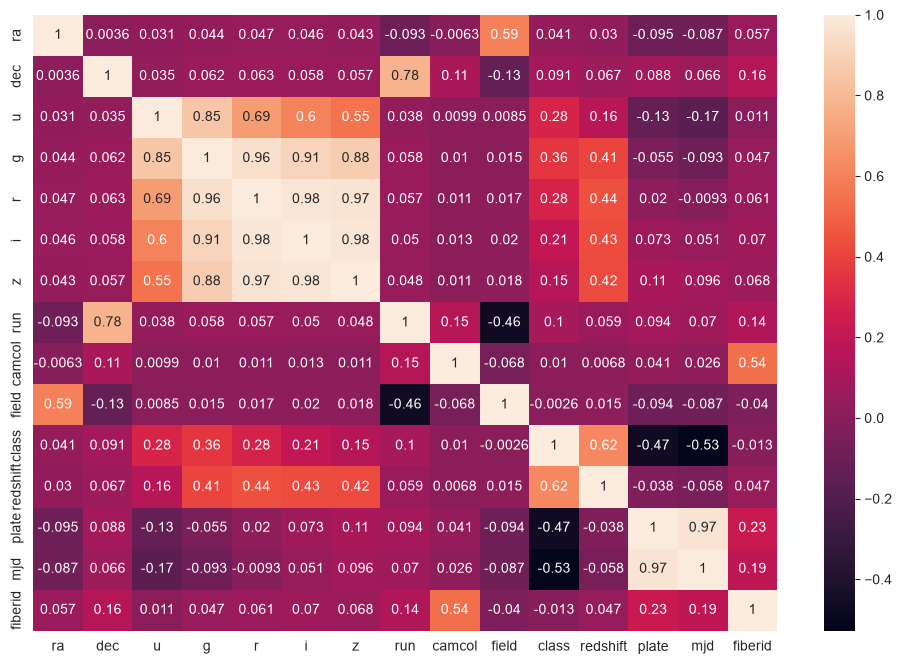

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

## ✂️ 6. Zayıf Kolonların Atılması / Dropping Weak Columns

**🇹🇷 Türkçe:**
Korelasyon haritasına bakıldıktan sonra `field` ve `fiberid` de çıkarılıyor. Bunlar teleskopun kayıt sistemine ait teknik numaralar; cismin fiziksel özellikleriyle ilgili bir bilgi taşımıyorlar.

**🇬🇧 English:**
After reviewing the correlation map, `field` and `fiberid` are also dropped. These are technical bookkeeping numbers from the telescope's recording system and carry no information about the object's physical properties.

In [16]:
df = df.drop(["field","fiberid"],axis=1)

## 📈 7. Sınıfların Görsel Ayrımı / Visual Separation of the Classes

**🇹🇷 Türkçe:**
Saçılım grafikleriyle sınıfların özellik uzayında nasıl ayrıldığı inceleniyor. `redshift` eksenine bakıldığında ayrımın ne kadar net olduğu görülüyor:

- **Yıldızlar (0)** kırmızıya kaymanın sıfır olduğu çizgide toplanıyor
- **Galaksiler (1)** düşük pozitif kırmızıya kayma bandında
- **Kuasarlar (2)** çok daha yüksek `redshift` değerlerinde, ayrı bir bulut halinde

Son grafikte (`u` ve `r` karşılaştırması) sadece parlaklık kullanıldığında sınıfların iç içe geçtiği, yani `redshift`'in bu problemde neden bu kadar kritik olduğu görülüyor.

**🇬🇧 English:**
Scatter plots are used to inspect how the classes separate in feature space. Along the `redshift` axis the separation is striking:

- **Stars (0)** cluster along the line where redshift is zero
- **Galaxies (1)** occupy a band of low positive redshift
- **Quasars (2)** form a separate cloud at much higher `redshift` values

The final plot (`u` against `r`) shows that using brightness alone leaves the classes overlapping — which is exactly why `redshift` is so critical for this problem.

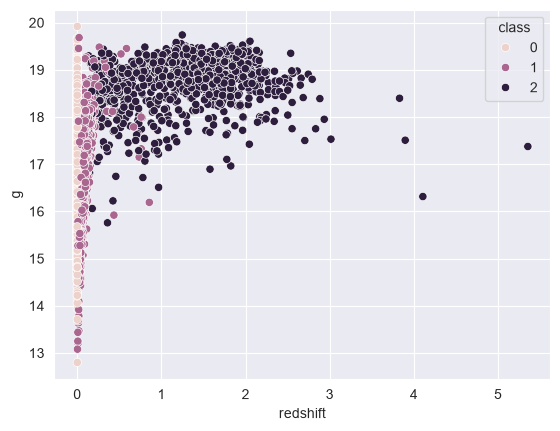

In [17]:
sns.scatterplot(x=df["redshift"],y=df["g"], hue=df["class"])
plt.show()

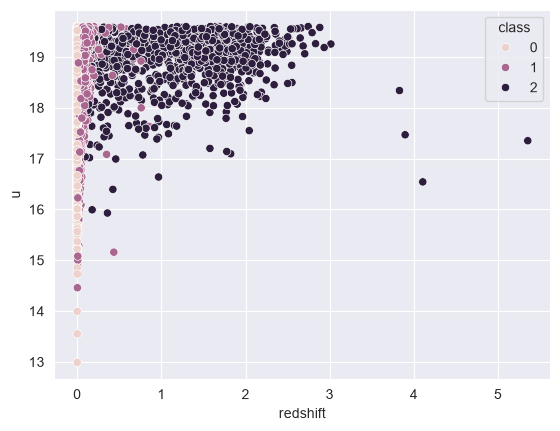

In [18]:
sns.scatterplot(x=df["redshift"],y=df["u"], hue=df["class"])
plt.show()

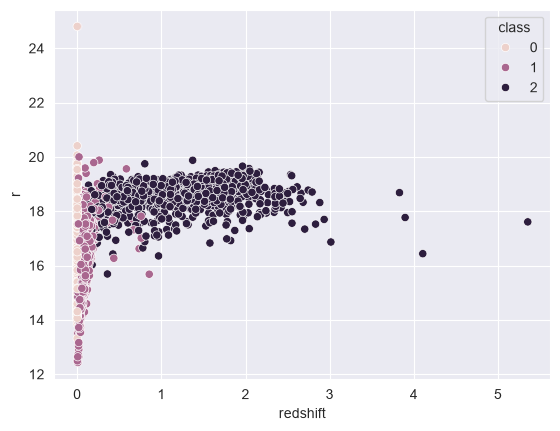

In [19]:
sns.scatterplot(x=df["redshift"],y=df["r"], hue=df["class"])
plt.show()

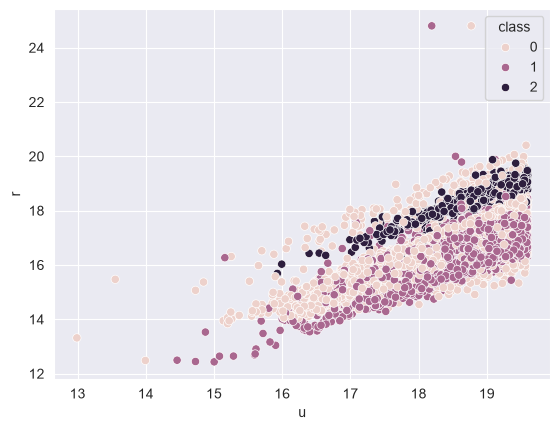

In [20]:
sns.scatterplot(x=df["u"],y=df["r"], hue=df["class"])
plt.show()

## 🚀 8. XGBoost Modeli / The XGBoost Model

**🇹🇷 Türkçe:**
Veri `train_test_split` ile yüzde 80 eğitim / yüzde 20 test olarak ayrılıyor. `stratify=y` parametresi önemli: azınlık sınıf QSO'nun her iki tarafta da aynı oranda temsil edilmesini garanti ediyor, aksi halde 850 örneklik sınıf test setinde dengesiz dağılabilirdi.

Model parametreleri:
- **`n_estimators=300`** — sırayla eklenen ağaç sayısı
- **`learning_rate=0.1`** — her ağacın nihai tahmine katkı payı; küçük değerler aşırı öğrenmeyi (overfitting) yavaşlatır
- **`max_depth=5`** — her ağacın derinliği; boosting'de sığ ağaçlar tercih edilir

**🇬🇧 English:**
The data is split 80% train / 20% test with `train_test_split`. The `stratify=y` parameter matters here: it guarantees that the minority QSO class is represented in the same proportion on both sides — otherwise a class with only 850 examples could be distributed unevenly across the test set.

Model parameters:
- **`n_estimators=300`** — the number of trees added sequentially
- **`learning_rate=0.1`** — how much each tree contributes to the final prediction; smaller values slow down overfitting
- **`max_depth=5`** — the depth of each tree; boosting favors shallow trees

In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop("class", axis=1)
y = df['class']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_tr, y_tr)
print(classification_report(y_te, model.predict(X_te)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       0.99      0.99      0.99      1000
           2       0.95      0.96      0.96       170

    accuracy                           0.99      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000



## ✅ 9. Sonuçlar ve Notlar / Results and Notes

**🇹🇷 Türkçe:**
Model test setinde **yüzde 99 doğruluk** elde ediyor. Sınıf bazında:

| Sınıf | Precision | Recall | Destek |
|---|---|---|---|
| STAR (0) | 1.00 | 1.00 | 830 |
| GALAXY (1) | 0.99 | 0.99 | 1000 |
| QSO (2) | 0.95 | 0.96 | 170 |

En zorlanılan sınıf beklendiği gibi **QSO** — hem en az örneğe sahip hem de galaksilerle sınırda kalan cisimler içeriyor.

**⚠️ Dürüst bir not:** Bu skorun büyük kısmı `redshift`'ten geliyor. Astrofizikte kırmızıya kayma cismin türüyle doğrudan ilişkili gerçek bir ölçüm olduğu için bu meşru bir özellik. Ancak veri setinde hâlâ duran `run`, `camcol`, `plate` ve `mjd` kolonları teleskopun gözlem programına ait teknik kodlar; SDSS belirli hedef türlerini belirli plakalarla gözlemlediği için bu kolonlar modele az miktarda ezber imkânı da veriyor olabilir. Daha temiz bir kurulum için yalnızca `u, g, r, i, z, redshift, ra, dec` ile eğitmek denenebilir.

**🇬🇧 English:**
The model reaches **99% accuracy** on the test set. Per class:

| Class | Precision | Recall | Support |
|---|---|---|---|
| STAR (0) | 1.00 | 1.00 | 830 |
| GALAXY (1) | 0.99 | 0.99 | 1000 |
| QSO (2) | 0.95 | 0.96 | 170 |

As expected, **QSO** is the hardest class — it has the fewest examples and includes objects that sit near the boundary with galaxies.

**⚠️ An honest note:** Much of this score comes from `redshift`. That is a legitimate feature, since in astrophysics redshift is a real measurement directly tied to object type. However, the `run`, `camcol`, `plate`, and `mjd` columns still present in the data are technical codes from the telescope's observing program; because SDSS targets specific object types with specific plates, these columns may give the model a small amount of memorization to exploit. A cleaner setup would be to train using only `u, g, r, i, z, redshift, ra, dec`.